# Prepoznavanje glazbenog žanra pomoću strojnog učenja

**Studentski projekt — klasifikacija glazbe po žanru na temelju audio značajki**

## O projektu

U ovom studentskom projektu, uronjeno je u svijet strojnog učenja radi rješavanja izazova prepoznavanja glazbenog žanra isključivo na temelju audio značajki pjesama. Korišten je bogati Spotify dataset koji sadrži brojne podatke poput `danceability` (mjerilo prikladnosti pjesme za ples), `energy`, `tempo`, `valence` (mjerilo pozitivnosti/veselosti), i mnoge druge. Cilj je bio osposobiti model strojnog učenja da, samo na temelju tih brojeva, predvidi glazbeni žanr.

Projekt je podijeljen u logične cjeline, korak po korak, kako bi se pratio cijeli proces:

1.  **Učitavanje i pregled podataka**: Prvi korak je upoznavanje s podacima.
2.  **Eksploratorna analiza podataka (EDA)**: Vizualizacija i dublje razumijevanje sadržaja podataka.
3.  **Predobrada podataka**: Priprema podataka za modele, uključujući rješavanje nedostajućih vrijednosti i skaliranje.
4.  **Treniranje modela** strojnog učenja: Uspoređena su dva različita algoritma radi odabira učinkovitijeg.
5.  **Evaluacija modela**: Nije dovoljno samo trenirati model; nužno je procijeniti njegovu učinkovitost. Analizirana je točnost, matrica zabune te važnost značajki za model.
6.  **Spremanje istreniranog modela**: Nakon evaluacije, model je spremljen radi buduće upotrebe.
7.  **Interaktivni upload**: Ovdje je moguće učitati datoteku (bilo CSV s audio značajkama ili audio datoteku .mp3/.wav) i vidjeti kako model predviđa žanr.

## Skup podataka (dataset)

Dataset sadrži sljedeće ključne stupce:

-   `Artist Name`, `Track Name` - Ime izvođača i naziv pjesme – ovi podaci služe isključivo za informaciju.
-   `Popularity` - Popularnost pjesme (broj od 0 do 100).
-   `danceability` - Mjeri koliko je pjesma prikladna za ples (vrijednost od 0 do 1).
-   `energy` - Percepcija intenziteta i aktivnosti (od 0 do 1).
-   `key` - Tonalitet pjesme (brojčana oznaka od 0 do 11, kao "pitch class").
-   `loudness` - Prosječna glasnoća u decibelima (dB).
-   `mode` - Označava je li pjesma mol (0) ili dur (1).
-   `speechiness` - Prisutnost govora u pjesmi (od 0 do 1).
-   `acousticness` - Mjera akustičnosti pjesme (od 0 do 1).
-   `instrumentalness` - Predviđa odsutnost vokala (od 0 do 1).
-   `liveness` - Detekcija prisutnosti publike ili izvedbe uživo (od 0 do 1).
-   `valence` - Pozitivnost/veselost pjesme (od 0 do 1).
-   `tempo` - Tempo pjesme u BPM-u (beats per minute).
-   `duration_in min/ms` - Trajanje pjesme u minutama ili milisekundama.
-   `time_signature` - Takt pjesme.
-   `Class` - Ciljna varijabla, šifra žanra (od 0 do 10), koja će biti predviđena.

Šifre žanrova (`Class`) bit će prevedene u čitljiva imena u sljedećoj ćeliji radi jasnoće i razumljivosti.

## 0. Preuzimanje dataseta s Kaggle-a (`kagglehub`)

Ovaj dataset preuzet je s platforme Kaggle, bogatog izvora podataka. Korištenjem biblioteke `kagglehub` omogućeno je direktno preuzimanje dataseta, eliminirajući potrebu za ručnim preuzimanjem datoteka.

In [ ]:
# Preuzimanje dataseta direktno s Kagglea pomoću kagglehub biblioteke

!pip install kagglehub --quiet

import kagglehub
import os

# Download latest version
# NOTE: Keeping this line as per user's instruction, but aware of potential caching issues.
path = kagglehub.dataset_download("purumalgi/music-genre-classification")

print("Path to dataset files:", path)

100%|██████████| 1.29M/1.29M [00:00<00:00, 48.6MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/purumalgi/music-genre-classification/versions/1


Nakon uspješnog preuzimanja dataseta, varijabla `path` ukazuje na lokaciju CSV datoteka. Radi osiguranja fluidnosti u daljnjem radu bilježnice, `DATA_DIR` je automatski postavljen da koristi navedenu putanju. Time je osigurana ispravna dostupnost podataka.

In [ ]:
!pip install ipywidgets librosa joblib scikit-learn pandas matplotlib seaborn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import joblib
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Biblioteke uspješno učitane")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 30.7 MB/s eta 0:00:00
Biblioteke uspješno učitane


## 1. Učitavanje podataka

Slijedi učitavanje podataka. Dostupne su dvije glavne datoteke: `train.csv`, koja sadrži podatke za treniranje modela (uključujući pjesme i njihove žanrove u stupcu `Class`), te `test.csv`, namijenjen za predviđanje žanra pjesama čiji žanr nije poznat. Datoteka `test.csv` bit će korištena isključivo za demonstraciju funkcionalnosti modela u praksi.

Podaci će biti učitani i pregledani.

In [ ]:
# Using the 'path' variable set by kagglehub.dataset_download in the previous cell.
# This variable now correctly points to the extracted dataset location.
DATA_DIR = path + os.sep

train_df = pd.read_csv(DATA_DIR + "train.csv")
test_df = pd.read_csv(DATA_DIR + "test.csv")

print(f"Broj pjesama za treniranje: {train_df.shape[0]}")
print(f"Broj značajki: {train_df.shape[1]}")
train_df.head()

Broj pjesama za treniranje: 17996
Broj značajki: 17


,Artist Name,Track Name,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature,Class
0,Bruno Mars,That's What I Like (feat. Gucci Mane),60.0,0.854,0.564,1.0,-4.964,1,0.0485,0.017100,NaN,0.0849,0.8990,134.071,234596.0,4,5
1,Boston,Hitch a Ride,54.0,0.382,0.814,3.0,-7.230,1,0.0406,0.001100,0.004010,0.1010,0.5690,116.454,251733.0,4,10
2,The Raincoats,No Side to Fall In,35.0,0.434,0.614,6.0,-8.334,1,0.0525,0.486000,0.000196,0.3940,0.7870,147.681,109667.0,4,6
3,Deno,Lingo (feat. J.I & Chunkz),66.0,0.853,0.597,10.0,-6.528,0,0.0555,0.021200,NaN,0.1220,0.5690,107.033,173968.0,4,5
4,Red Hot Chili Peppers,Nobody Weird Like Me - Remastered,53.0,0.167,0.975,2.0,-4.279,1,0.2160,0.000169,0.016100,0.1720,0.0918,199.060,229960.0,4,10


In [ ]:
# Rječnik koji prevodi šifru žanra (Class) u čitljivo ime

genre_map = {
    0: "Acoustic/Folk",
    1: "Alt_Music",
    2: "Blues",
    3: "Bollywood",
    4: "Country",
    5: "HipHop",
    6: "Indie Alt",
    7: "Instrumental",
    8: "Metal",
    9: "Pop",
    10: "Rock"
}

train_df["Genre"] = train_df["Class"].map(genre_map)
train_df[["Track Name", "Artist Name", "Class", "Genre"]].head(10)


,Track Name,Artist Name,Class,Genre
0,That's What I Like (feat. Gucci Mane),Bruno Mars,5,HipHop
1,Hitch a Ride,Boston,10,Rock
2,No Side to Fall In,The Raincoats,6,Indie Alt
3,Lingo (feat. J.I & Chunkz),Deno,5,HipHop
4,Nobody Weird Like Me - Remastered,Red Hot Chili Peppers,10,Rock
5,Search and Destroy - Iggy Pop Mix,The Stooges,6,Indie Alt
6,None Of Us Are Free,Solomon Burke,2,Blues
7,On the Other Hand,Randy Travis,4,Country
8,Slow,Professional Murder Music,8,Metal
9,"◊ì◊ï◊ì◊ï, ◊ô◊ê◊ú◊ú◊î ◊ô◊ê◊ú◊ú◊î",Dudu Aharon,9,Pop


## 2. Eksploratorna analiza podataka (EDA)

Prije treniranja modela, ključno je temeljito razumjeti podatke. Stoga se provodi eksploratorna analiza podataka (EDA). Cilj je identificirati distribuciju pjesama po žanrovima, provjeriti prisutnost nedostajućih vrijednosti koje mogu uzrokovati probleme te razumjeti međusobne odnose različitih značajki. Svrha je steći što bolji uvid u strukturu i karakteristike dataseta.

In [ ]:
# Osnovne informacije o skupu podataka
train_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17996 entries, 0 to 17995
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Artist Name         17996 non-null  object 
 1   Track Name          17996 non-null  object 
 2   Popularity          17568 non-null  float64
 3   danceability        17996 non-null  float64
 4   energy              17996 non-null  float64
 5   key                 15982 non-null  float64
 6   loudness            17996 non-null  float64
 7   mode                17996 non-null  int64  
 8   speechiness         17996 non-null  float64
 9   acousticness        17996 non-null  float64
 10  instrumentalness    13619 non-null  float64
 11  liveness            17996 non-null  float64
 12  valence             17996 non-null  float64
 13  tempo               17996 non-null  float64
 14  duration_in min/ms  17996 non-null  float64
 15  time_signature      17996 non-null  int64  
 16  Clas

In [ ]:
# Nedostajuće vrijednosti
missing = train_df.isnull().sum()
missing = missing[missing > 0]
print("Stupci s nedostajućim vrijednostima:")
print(missing)


Stupci s nedostajućim vrijednostima:
Popularity           428
key                 2014
instrumentalness    4377
dtype: int64


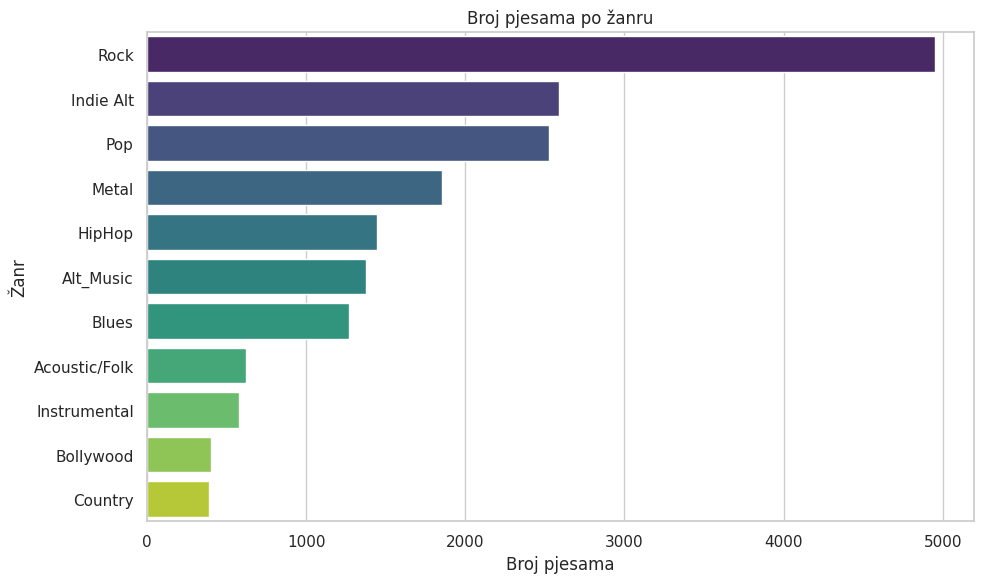

In [ ]:
# Distribucija žanrova u skupu podataka
plt.figure(figsize=(10, 6))
order = train_df["Genre"].value_counts().index
sns.countplot(data=train_df, y="Genre", order=order, palette="viridis")
plt.title("Broj pjesama po žanru")
plt.xlabel("Broj pjesama")
plt.ylabel("Žanr")
plt.tight_layout()
plt.show()


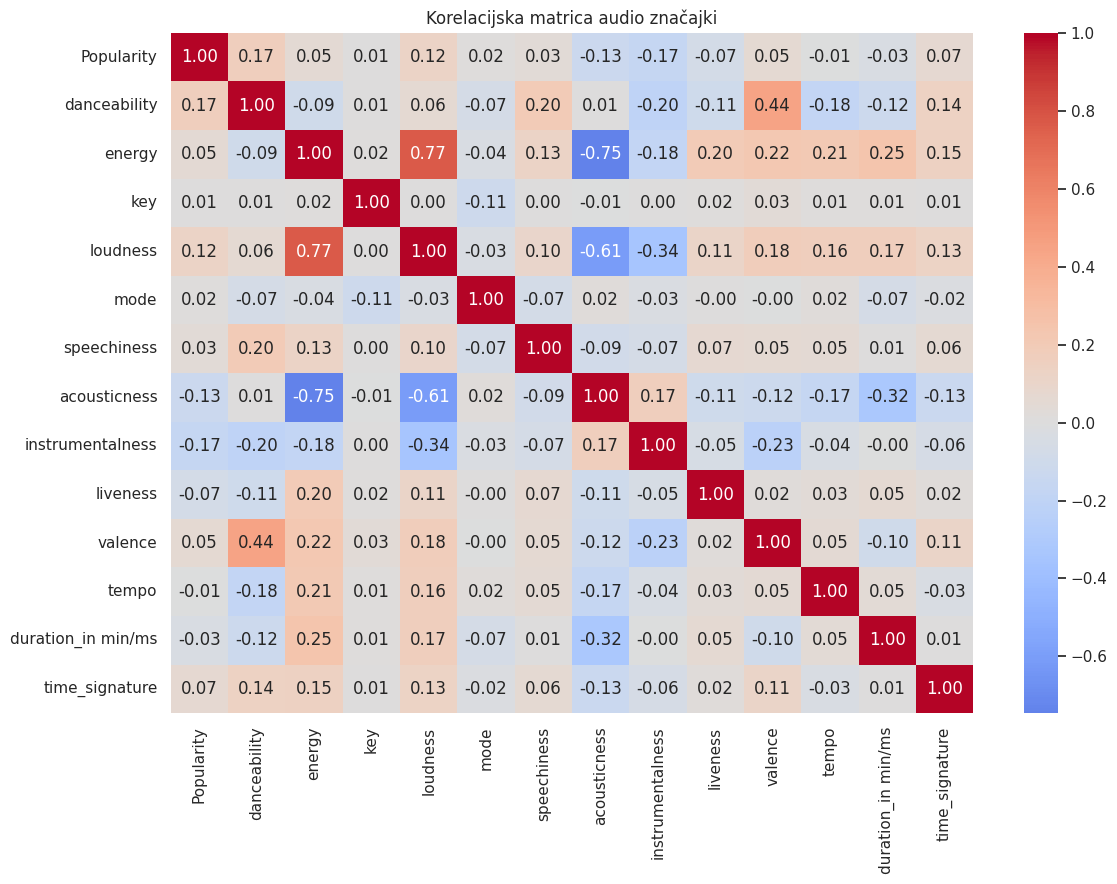

In [ ]:
# Korelacija numeričkih audio značajki
numeric_cols = ["Popularity", "danceability", "energy", "key", "loudness", "mode",
                 "speechiness", "acousticness", "instrumentalness", "liveness",
                 "valence", "tempo", "duration_in min/ms", "time_signature"]

plt.figure(figsize=(12, 9))
sns.heatmap(train_df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Korelacijska matrica audio značajki")
plt.tight_layout()
plt.show()


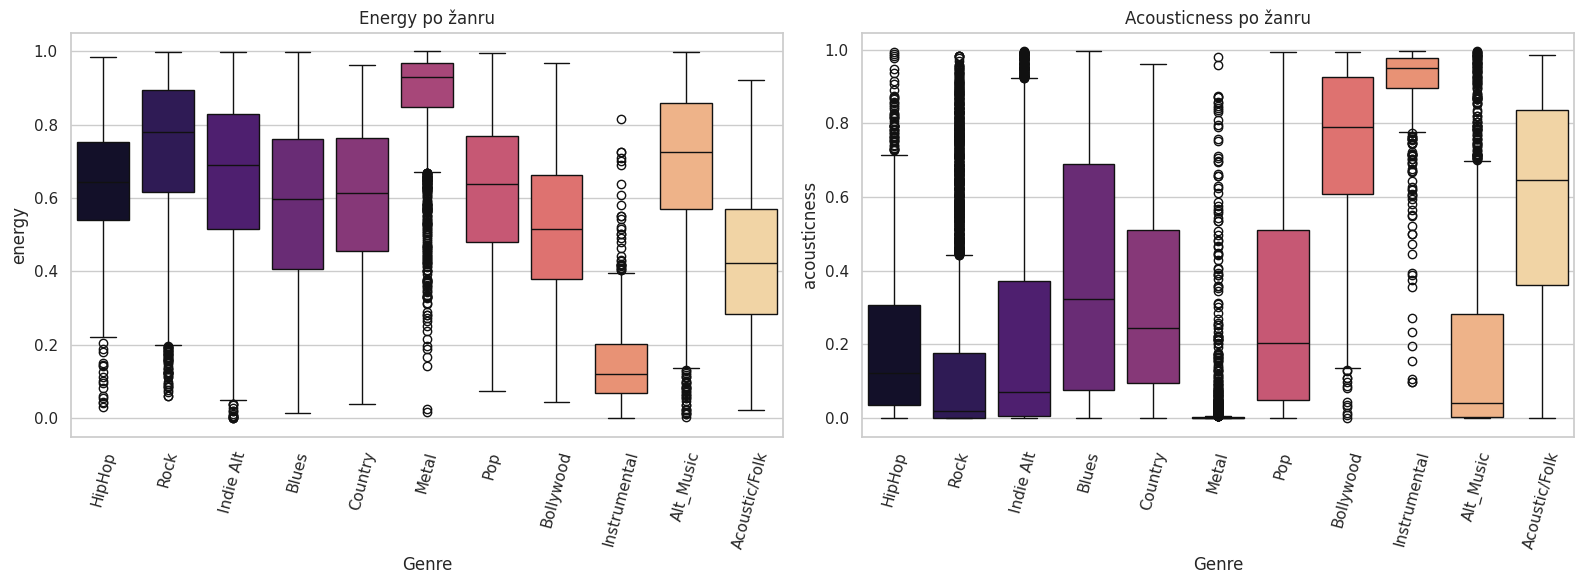

In [ ]:
# Kako se npr. energy i acousticness razlikuju po žanru
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=train_df, x="Genre", y="energy", ax=axes[0], palette="magma")
axes[0].set_title("Energy po žanru")
axes[0].tick_params(axis="x", rotation=75)

sns.boxplot(data=train_df, x="Genre", y="acousticness", ax=axes[1], palette="magma")
axes[1].set_title("Acousticness po žanru")
axes[1].tick_params(axis="x", rotation=75)

plt.tight_layout()
plt.show()


## 3. Predobrada podataka

Priprema podataka predstavlja ključan korak. Prije pokretanja procesa učenja modela, potrebno je provesti nekoliko ključnih koraka predobrade:

1.  **Odabir značajki**: Pažljivo su odabrani stupci koji će se koristiti kao ulazne značajke. `Artist Name` i `Track Name` su informativni, no ne pružaju direktne informacije o zvučnim karakteristikama pjesme, stoga su izostavljeni.
2.  **Podjela podataka**: Podaci su podijeljeni na tri dijela: skup za treniranje, skup za validaciju i **potpuno odvojeni testni skup**. Ova podjela omogućuje pouzdanu procjenu performansi modela.
3.  **Popunjavanje i standardizacija**: Nedostajuće vrijednosti popunjene su medijanom (izračunatim **isključivo na skupu za treniranje** radi sprječavanja "curenja" informacija). Sve značajke su također standardizirane, budući da mnogi modeli postižu bolje rezultate kada su vrijednosti na sličnoj skali.

Ova troslojna podjela (treniranje / validacija / testiranje) koristi se radi dobivanja što objektivnije procjene. Validacijski skup koristi se isključivo za fino podešavanje modela i odabir optimalnog, dok je testni skup sačuvan netaknutim radi dobivanja "prave" i nepristrane ocjene performansi.

In [ ]:
feature_cols = ["Popularity", "danceability", "energy", "key", "loudness", "mode",
                "speechiness", "acousticness", "instrumentalness", "liveness",
                "valence", "tempo", "duration_in min/ms", "time_signature"]

X = train_df[feature_cols].copy()
y = train_df["Class"].copy()


In [ ]:
# Troslojna podjela: 60% treniranje, 20% validacija, 20% test.
# Prvo odvajamo test skup, pa preostatak dijelimo na train i validaciju.
# Test skup se od ovog trenutka NE dira sve do poglavlja 6.

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)  # 0.25 od preostalih 80% = 20% ukupnog skupa

print(f"Skup za treniranje: {X_train.shape[0]} pjesama")
print(f"Skup za validaciju:  {X_val.shape[0]} pjesama")
print(f"Test skup: {X_test.shape[0]} pjesama")


Skup za treniranje: 10797 pjesama
Skup za validaciju:  3599 pjesama
Test skup (dira se samo jednom, na kraju): 3600 pjesama


In [ ]:
# Popunjavanje nedostajućih vrijednosti - medijan računamo ISKLJUČIVO na skupu za treniranje,
# a te iste vrijednosti zatim primjenjujemo na validaciju i test.
# Da smo medijan računali na cijelom skupu prije podjele (kao u ranijoj verziji ove bilježnice),
# informacija o validacijskim/test primjerima bi se neizravno "procurila" u pripremu podataka.

medians = X_train.median()

X_train = X_train.fillna(medians)
X_val = X_val.fillna(medians)
X_test = X_test.fillna(medians)

print("Nedostajuće vrijednosti u train skupu nakon popunjavanja:", X_train.isnull().sum().sum())


Nedostajuće vrijednosti u train skupu nakon popunjavanja: 0


In [ ]:
# Standardizacija značajki (srednja vrijednost 0, standardna devijacija 1)
# scaler se također fitta isključivo na train skupu, iz istog razloga kao gore.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


## 4. Treniranje modela

Prije implementacije složenijih modela, korisno je definirati "donju granicu" ili *baseline*. Bez tog referentnog okvira, teško je procijeniti relevantnost, primjerice, 50% točnosti u problemu s 11 različitih žanrova. Stoga su inicijalno primijenjena dva jednostavna pristupa:

-   **Uvijek predvidi najčešći žanr**: U datasetu je to Rock. Ovo je ekvivalentno kontinuiranom predviđanju "Rock" žanra.
-   **Nasumično, ali pametno**: U ovom pristupu model nasumično predviđa žanr, uzimajući u obzir zastupljenost žanrova u podacima. Ovo se može usporediti s bacanjem kocke gdje su vjerojatnosti ishoda prilagođene učestalosti žanrova.

Nakon definiranja *baseline* modela, prelazi se na implementaciju složenijih modela. Odabrana su dva popularna i učinkovita algoritma:

-   **Logistička regresija (Logistic Regression)**: Jednostavan, brz i linearan model, pogodan za inicijalnu analizu.
-   **Slučajna šuma (Random Forest)**: Ovaj algoritam predstavlja ansambl (skup) stabala odluke, koji je često učinkovitiji i sposobniji za modeliranje složenih, nelinearnih odnosa među značajkama.

Svi ovi modeli (uključujući *baselinove*) bit će uspoređeni na validacijskom skupu radi odabira optimalnog. Odabrani model bit će evaluiran na testnom skupu (poglavlje 6) za konačnu, nepristranu procjenu.

In [ ]:
from sklearn.dummy import DummyClassifier

# Baseline 1: uvijek predvidi najčešći žanr
dummy_most_frequent = DummyClassifier(strategy="most_frequent", random_state=42)
dummy_most_frequent.fit(X_train_scaled, y_train)
dummy_mf_acc = accuracy_score(y_val, dummy_most_frequent.predict(X_val_scaled))

# Baseline 2: nasumično, ali u skladu s učestalošću žanrova u train skupu
dummy_stratified = DummyClassifier(strategy="stratified", random_state=42)
dummy_stratified.fit(X_train_scaled, y_train)
dummy_strat_acc = accuracy_score(y_val, dummy_stratified.predict(X_val_scaled))

print(f"Baseline (uvijek najčešći žanr) — točnost na validaciji: {dummy_mf_acc:.3f}")
print(f"Baseline (nasumično po učestalosti) — točnost na validaciji: {dummy_strat_acc:.3f}")


Baseline (uvijek najčešći žanr) — točnost na validaciji: 0.275
Baseline (nasumično po učestalosti) — točnost na validaciji: 0.140


In [ ]:
# Logistic Regression
log_reg = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
log_reg.fit(X_train_scaled, y_train)

log_reg_preds = log_reg.predict(X_val_scaled)
log_reg_acc = accuracy_score(y_val, log_reg_preds)
print(f"Logistic Regression — točnost na validaciji: {log_reg_acc:.3f}")


Logistic Regression — točnost na validaciji: 0.444


In [ ]:
# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)

rf_preds = rf_model.predict(X_val_scaled)
rf_acc = accuracy_score(y_val, rf_preds)
print(f"Random Forest — točnost na validaciji: {rf_acc:.3f}")


Random Forest — točnost na validaciji: 0.517


In [ ]:
# Usporedba svih pristupa (baseline i stvarni modeli) i odabir najboljeg
results = pd.DataFrame({
    "Model": ["Baseline (najčešći žanr)", "Baseline (nasumično po učestalosti)",
              "Logistic Regression", "Random Forest"],
    "Tocnost": [dummy_mf_acc, dummy_strat_acc, log_reg_acc, rf_acc]
}).sort_values("Tocnost", ascending=False)

print(results.to_string(index=False))
print(f"\nRandom Forest je {rf_acc / dummy_mf_acc:.1f}x bolji od baseline-a koji uvijek predvidi najčešći žanr.")

best_model = rf_model if rf_acc >= log_reg_acc else log_reg
best_preds = rf_preds if rf_acc >= log_reg_acc else log_reg_preds
best_name = "Random Forest" if rf_acc >= log_reg_acc else "Logistic Regression"

print(f"\nNajbolji model (odabran na validacijskom skupu): {best_name}")


                              Model  Tocnost
                      Random Forest 0.517088
                Logistic Regression 0.444290
           Baseline (najčešći žanr) 0.275076
Baseline (nasumično po učestalosti) 0.139761

Random Forest je 1.9x bolji od baseline-a koji uvijek predvidi najčešći žanr.

Najbolji model (odabran na validacijskom skupu): Random Forest


## 5. Evaluacija modela

Nije dovoljno poznavati samo ukupnu točnost modela; nužno je razumjeti kako se ovaj model ponaša sa **svakim pojedinim žanrom**. Ukupna točnost može biti zavaravajuća, jer neki žanrovi (poput "Instrumental" ili "Bollywood") mogu posjedovati vrlo distinktivne značajke koje olakšavaju prepoznavanje. Nasuprot tome, žanrovi poput "Alt_Music" i "Indie Alt" su glazbeno vrlo slični, što može rezultirati poteškoćama u njihovom razlikovanju od strane modela. Stoga se detaljno analiziraju rezultati, uključujući izvještaj o klasifikaciji i matricu zabune, radi stjecanja cjelovitog uvida.

In [ ]:
target_names = [genre_map[i] for i in sorted(genre_map.keys())]
print(classification_report(y_val, best_preds, target_names=target_names))


               precision    recall  f1-score   support

Acoustic/Folk       0.70      0.86      0.77       125
    Alt_Music       0.05      0.03      0.03       275
        Blues       0.55      0.42      0.47       254
    Bollywood       0.85      0.76      0.80        80
      Country       0.71      0.62      0.66        78
       HipHop       0.67      0.70      0.68       289
    Indie Alt       0.33      0.27      0.29       517
 Instrumental       0.96      0.96      0.96       115
        Metal       0.61      0.47      0.53       371
          Pop       0.56      0.54      0.55       505
         Rock       0.47      0.64      0.54       990

     accuracy                           0.52      3599
    macro avg       0.59      0.57      0.57      3599
 weighted avg       0.50      0.52      0.50      3599



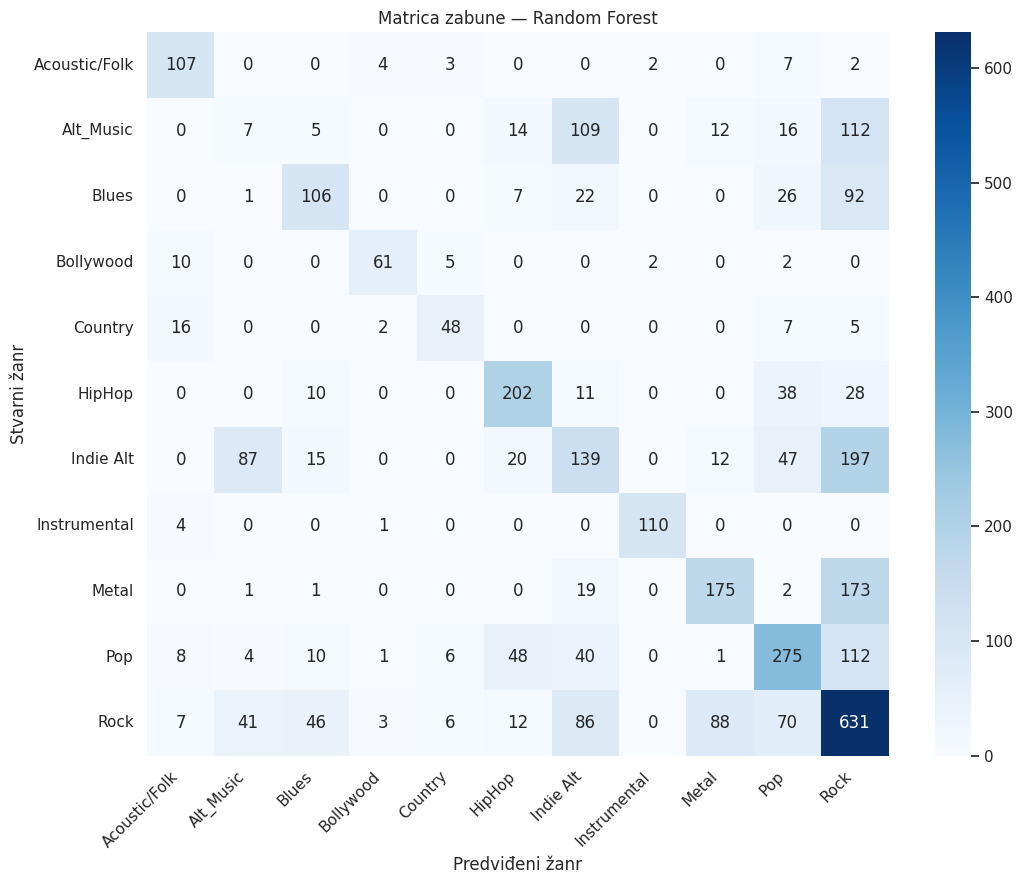

In [ ]:
# Matrica zabune (confusion matrix)
cm = confusion_matrix(y_val, best_preds)

plt.figure(figsize=(11, 9))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_names, yticklabels=target_names)
plt.title(f"Matrica zabune — {best_name}")
plt.xlabel("Predviđeni žanr")
plt.ylabel("Stvarni žanr")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### 5.1 Zašto Alt_Music pokazuje lošije rezultate u usporedbi s ostalim žanrovima

Primijećeno je da "Alt_Music" u izvještaju sustavno pokazuje najnižu uspješnost. Prije zaključivanja o učinkovitosti modela, potrebno je razumjeti razloge ovakvog ponašanja. Pitanje je da li se "Alt_Music" prečesto klasificira kao neki drugi žanr. Detaljno će se analizirati s kojim žanrovima se ovaj model najčešće zbunjuje u kontekstu "Alt_Music".

In [ ]:
alt_music_class = [k for k, v in genre_map.items() if v == "Alt_Music"][0]
alt_music_row = cm[alt_music_class]

zamjene = pd.Series(alt_music_row, index=target_names).sort_values(ascending=False)
print("S čime se Alt_Music najčešće zamjenjuje (u validacijskom skupu):")
print(zamjene)


S čime se Alt_Music najčešće zamjenjuje (u validacijskom skupu):
Rock             112
Indie Alt        109
Pop               16
HipHop            14
Metal             12
Alt_Music          7
Blues              5
Acoustic/Folk      0
Country            0
Bollywood          0
Instrumental       0
dtype: int64


Vidimo da se najčešće buni s "Rock" i "Indie Alt" žanrovima. Kako bi provjerili postoji li tu neki komplicirani razlog, želimo provjeriti je li se možda značajke ova tri žanra previše preklapaju, i je li to uzrok lošeg prepoznavanja.

Odabiremo značajke 'energy', 'acousticness' i 'valence' zbog njihove važnosti za razlikovanje žanrova. 'Energy' opisuje intenzitet, 'acousticness' prisutnost akustičnih zvukova, a 'valence' emocionalni ton pjesme. Ove značajke pružaju jasan uvid u preklapanje ili razlike među žanrovima.

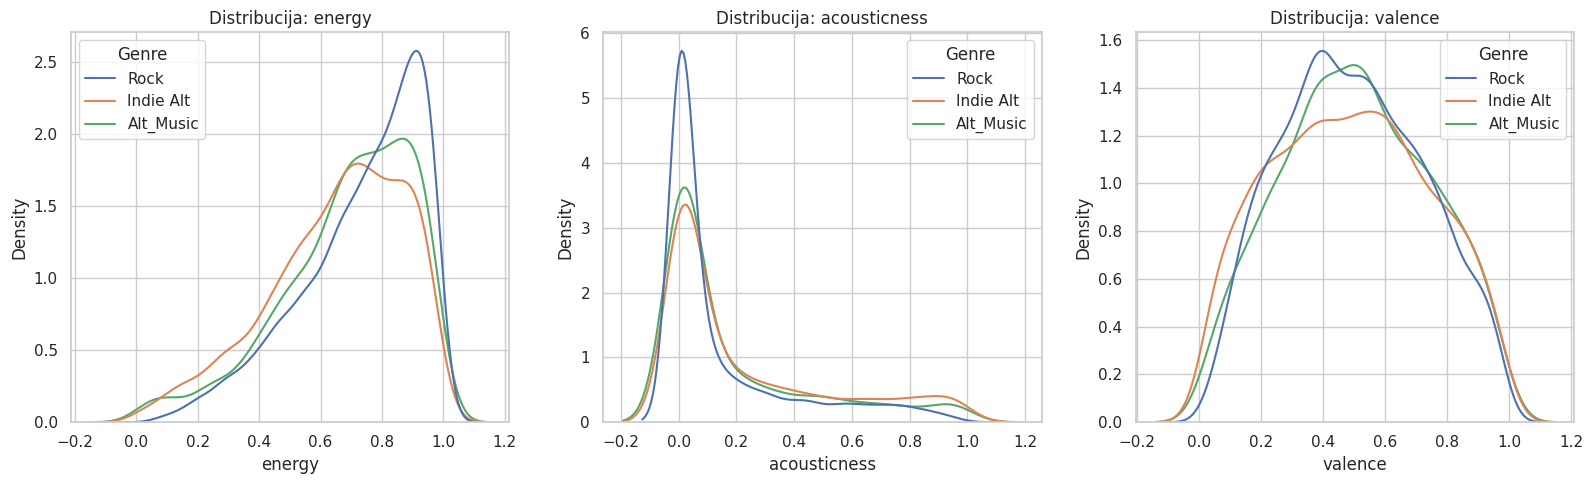

In [ ]:
# Koliko se Alt_Music preklapa s Indie Alt i Rock po ključnim značajkama
usporedba_zanrova = ["Alt_Music", "Indie Alt", "Rock"]
subset = train_df[train_df["Genre"].isin(usporedba_zanrova)]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, ["energy", "acousticness", "valence"]):
    sns.kdeplot(data=subset, x=col, hue="Genre", ax=ax, common_norm=False)
    ax.set_title(f"Distribucija: {col}")
plt.tight_layout()
plt.show()


Analiza distribucije ključnih audio značajki ('energy', 'acousticness', 'valence') za žanrove "Alt_Music", "Indie Alt" i "Rock" vizualno potvrđuje značajno preklapanje distribucija, posebno između "Alt_Music" i "Indie Alt". Ovo snažno sugerira da je primijećeni problem u razlikovanju ovih žanrova prvenstveno uzrokovan nedovoljnom diskriminacijskom moći samih audio značajki, a ne samo nedostatkom učinkovitosti modela. Drugim riječima, podaci jednostavno ne pružaju dovoljno jasne signale za pouzdano razdvajanje ovih specifičnih žanrova.



### 5.2 Provjera pouzdanosti predviđanja modela (kalibracija)

Model uz svako predviđanje pruža i vjerojatnost (na primjer, "38,8% vjerojatnosti da je ovo pop"). Prije prikazivanja te vrijednosti korisniku kao "pouzdanosti", nužno je provjeriti je li model **kalibriran**. To znači: ako model predviđa 40% sigurnosti, da li je približno 40% tih predviđanja točno? Želi se osigurati da je prikazana "pouzdanost" doista vjerodostojna.

Raspon_pouzdanosti  Prosjecna_prijavljena_pouzdanost  Stvarna_tocnost  Broj_primjera
           0.2-0.3                          0.271517         0.344322            273
           0.3-0.4                          0.353317         0.421291            883
           0.4-0.5                          0.448428         0.582711            937
           0.5-0.6                          0.545616         0.652985            536
           0.6-0.7                          0.653060         0.448441            417
           0.7-0.8                          0.747352         0.425926            324
           0.8-0.9                          0.839531         0.655405            148
           0.9-1.0                          0.950872         0.948718             78


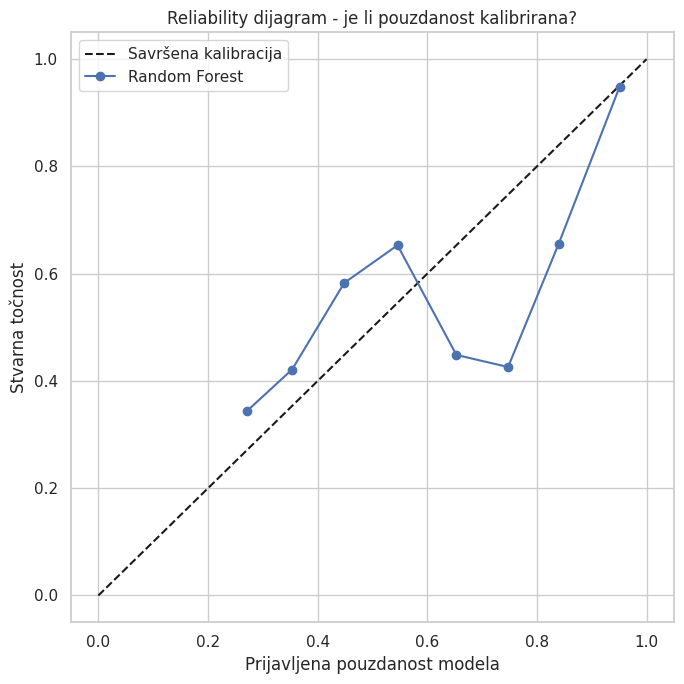

In [ ]:
val_probs = best_model.predict_proba(X_val_scaled)
val_confidence = val_probs.max(axis=1)
val_correct = (best_preds == y_val.values).astype(int)

bins = np.linspace(0, 1, 11)
bin_idx = np.digitize(val_confidence, bins) - 1

kalibracija = []
for b in range(len(bins) - 1):
    mask = bin_idx == b
    if mask.sum() > 0:
        kalibracija.append({
            "Raspon_pouzdanosti": f"{bins[b]:.1f}-{bins[b+1]:.1f}",
            "Prosjecna_prijavljena_pouzdanost": val_confidence[mask].mean(),
            "Stvarna_tocnost": val_correct[mask].mean(),
            "Broj_primjera": mask.sum()
        })

kalibracija_df = pd.DataFrame(kalibracija)
print(kalibracija_df.to_string(index=False))

plt.figure(figsize=(7, 7))
plt.plot([0, 1], [0, 1], "k--", label="Savršena kalibracija")
plt.plot(kalibracija_df["Prosjecna_prijavljena_pouzdanost"], kalibracija_df["Stvarna_tocnost"],
         marker="o", label=best_name)
plt.xlabel("Prijavljena pouzdanost modela")
plt.ylabel("Stvarna točnost")
plt.title("Reliability dijagram - je li pouzdanost kalibrirana?")
plt.legend()
plt.tight_layout()
plt.show()


Ako točke na grafikonu kalibracije leže ispod dijagonale, to ukazuje da je model **preoptimističan**. Drugim riječima, model je sigurniji u svoja predviđanja nego što je realno utemeljeno. Stoga vrijednost poput 38,8% ne bi smjela biti bezrezervno predstavljena korisniku kao "stvarna vjerojatnost" točnog pogotka. Ovo je važna informacija za interpretaciju rezultata.

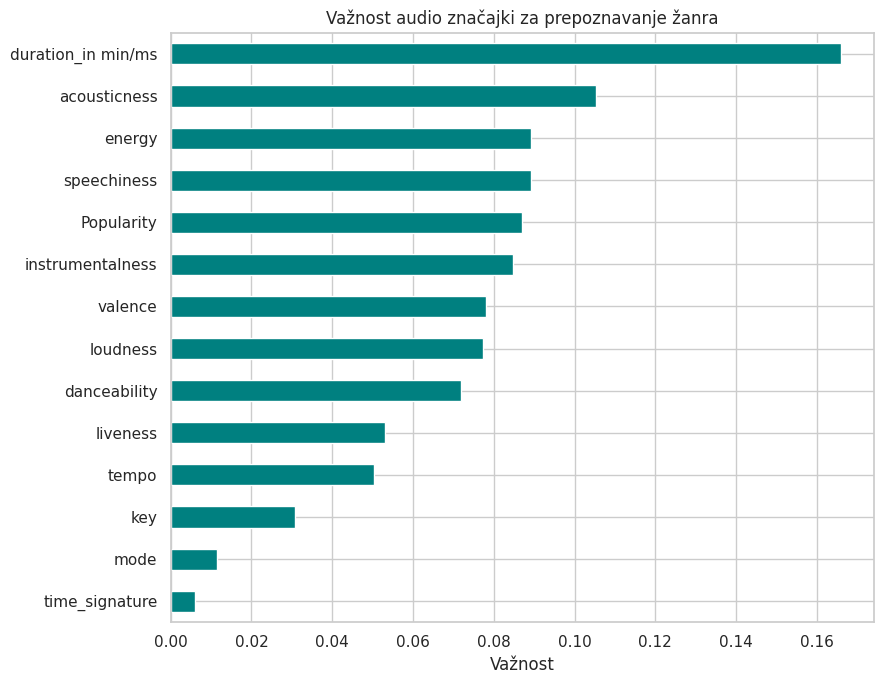

In [ ]:
# Važnost pojedinih značajki za konačnu odluku modela (radi samo za Random Forest)
if best_name == "Random Forest":
    importances = pd.Series(best_model.feature_importances_, index=feature_cols).sort_values(ascending=True)

    plt.figure(figsize=(9, 7))
    importances.plot(kind="barh", color="teal")
    plt.title("Važnost audio značajki za prepoznavanje žanra")
    plt.xlabel("Važnost")
    plt.tight_layout()
    plt.show()


## 6. Konačna provjera na testnom skupu

Slijedi ključan korak. Do sada je testni skup ostao netaknut – nije korišten u prethodnim fazama. Skupovi za treniranje i validaciju korišteni su isključivo za proces treniranja i odabira optimalnog modela. Sada će se odabrani model evaluirati na ovom testnom skupu. Ovo će omogućiti najobjektivniju i nepristranu procjenu stvarne točnosti modela.

In [ ]:
test_preds = best_model.predict(X_test_scaled)
test_acc = accuracy_score(y_test, test_preds)

print(f"Točnost na validaciji (korištena za odabir modela): {rf_acc if best_name == 'Random Forest' else log_reg_acc:.3f}")
print(f"Točnost na test skupu (konačna, nepristrana procjena): {test_acc:.3f}")
print(classification_report(y_test, test_preds, target_names=target_names))


Točnost na validaciji (korištena za odabir modela): 0.517
Točnost na test skupu (konačna, nepristrana procjena): 0.511
               precision    recall  f1-score   support

Acoustic/Folk       0.69      0.77      0.73       125
    Alt_Music       0.05      0.03      0.03       275
        Blues       0.50      0.32      0.39       254
    Bollywood       0.77      0.80      0.79        80
      Country       0.72      0.73      0.72        77
       HipHop       0.69      0.71      0.70       290
    Indie Alt       0.33      0.27      0.30       518
 Instrumental       0.94      0.91      0.93       115
        Metal       0.60      0.48      0.53       371
          Pop       0.54      0.52      0.53       505
         Rock       0.46      0.65      0.54       990

     accuracy                           0.51      3600
    macro avg       0.57      0.56      0.56      3600
 weighted avg       0.49      0.51      0.49      3600



Ako je točnost postignuta na testnom skupu vrlo slična onoj na validacijskom skupu, to je pozitivan indikator. To znači da se model dobro generalizira, odnosno da nije samo "zapamtio" podatke korištene za treniranje, već je naučio primjenjiva pravila. Ovo sugerira da rezultat na validaciji nije bio samo slučajna sreća, već stvarni pokazatelj performansi modela.

## 7. Spremanje istreniranog modela

Nakon odabira i evaluacije optimalnog modela, pristupa se njegovom spremanju. Spremanje uključuje sam model, `scaler` (koji osigurava identično skaliranje novih podataka kao i onih za treniranje) te rječnik žanrova (`genre_map`). Spremanjem ovih komponenti omogućuje se njihova ponovna upotreba bez potrebe za ponovnim treniranjem.

In [ ]:
joblib.dump(best_model, "genre_model.joblib")
joblib.dump(scaler, "genre_scaler.joblib")
joblib.dump(genre_map, "genre_map.joblib")
joblib.dump(feature_cols, "feature_cols.joblib")

print("Model, scaler i pomoćni podaci su spremljeni")


Model, scaler i pomoćni podaci su spremljeni


## 8. Funkcija za predviđanje žanra

Kreirana je funkcija `predict_genre` koja obavlja sve potrebne operacije. Funkcija prima rječnik s audio značajkama jedne pjesme (u formatu kakav model očekuje) i vraća predviđeni žanr, zajedno s razinom pouzdanosti (stupnjem sigurnosti modela u svoje predviđanje). Ako neka značajka nedostaje, funkcija će je automatski popuniti medijanom iz skupa za treniranje. Funkcija će biti demonstrirana.

In [ ]:
def predict_genre(features: dict):
    """
    Prima rječnik s audio značajkama (isti stupci kao feature_cols)
    i vraća (žanr, pouzdanost, sve_vjerojatnosti).
    Nedostajuće značajke se automatski popunjavaju medijanom iz skupa za treniranje.
    """
    row = {}
    for col in feature_cols:
        row[col] = features.get(col, medians[col])

    df_row = pd.DataFrame([row])[feature_cols]
    df_row_scaled = scaler.transform(df_row)

    pred_class = best_model.predict(df_row_scaled)[0]
    probs = best_model.predict_proba(df_row_scaled)[0]

    genre = genre_map[pred_class]
    confidence = probs.max()

    return genre, confidence, dict(zip(target_names, probs))


# Primjer: probajmo predvidjeti žanr za prvu pjesmu iz test.csv skupa
primjer = test_df.iloc[0][feature_cols].to_dict()
genre, confidence, probs = predict_genre(primjer)

print(f"Pjesma: {test_df.iloc[0]['Track Name']} — {test_df.iloc[0]['Artist Name']}")
print(f"Predviđeni žanr: {genre}")
print(f"Pouzdanost: {confidence*100:.1f}%")


Pjesma: Space Oddity - 2015 Remaster — David Bowie
Predviđeni žanr: Indie Alt
Pouzdanost: 48.8%


## 9. Interaktivni upload — testiranje modela na novim podacima

Ovaj dio demonstrira funkcionalnosti sustava. Nakon treniranja i spremanja modela, omogućuje se njegovo testiranje na potpuno novim podacima, koje model nikada prije nije obradio. U ovom dijelu, korisnici mogu učitati vlastitu datoteku i dobiti predviđeni žanr. Dizajnirana su dva načina za učitavanje datoteka, ovisno o njihovom formatu:

### Način A — CSV datoteka s audio značajkama (preporučeno, precizno)
Ako je dostupna CSV datoteka koja već sadrži audio značajke (poput onih u priloženoj `test.csv` — `danceability`, `energy`, `tempo`, itd.), ovo predstavlja optimalan i najprecizniji način. Model će za svaku pjesmu u učitanoj datoteci predvidjeti žanr s najvećom točnošću, budući da koristi iste značajke na kojima je treniran.

### Način B — Audio datoteka (.mp3 / .wav) — eksperimentalno
Ovdje je moguće učitati **stvarnu pjesmu** (u formatu mp3 ili wav). Program će tada koristiti biblioteku `librosa` za **procjenu** audio značajki iz zvučnog zapisa koje su potrebne modelu. Tek tada se te procijenjene značajke prosljeđuju modelu za predviđanje žanra.

> **Važna napomena:** Važno je naglasiti sljedeće: Spotify koristi vlastite algoritme strojnog učenja za izračunavanje značajki poput `danceability` ili `valence`. Biblioteka `librosa` ih ne može reproducirati identično. Stoga se ovdje koriste razumne **aproksimacije** temeljene na naprednoj obradi zvučnog signala (npr. omjer harmonijskog i perkusivnog sadržaja kao metoda za procjenu akustičnosti). Iako je rezultat izvanredan za demonstraciju cjelokupnog sustava, važno je ovo shvatiti kao **procjenu**, a ne kao znanstveno točnu mjeru identičnu Spotifyjevoj.

In [ ]:
# Ćelija A — funkcija za obradu CSV uploada
import io

def predvidi_iz_csv(df_new: pd.DataFrame):
    """Predviđa žanr za svaki red u uploadanom CSV-u."""
    missing_cols = [c for c in feature_cols if c not in df_new.columns]
    if missing_cols:
        print(f"Datoteci nedostaju potrebni stupci: {missing_cols}")
        print(f"Potrebni stupci su: {feature_cols}")
        return None

    X_new = df_new[feature_cols].copy().fillna(medians)
    X_new_scaled = scaler.transform(X_new)

    preds = best_model.predict(X_new_scaled)
    probs = best_model.predict_proba(X_new_scaled)

    result = df_new.copy()
    result["Predvidjeni_zanr"] = [genre_map[p] for p in preds]
    result["Pouzdanost"] = probs.max(axis=1).round(3)

    display_cols = [c for c in ["Artist Name", "Track Name"] if c in result.columns]
    display_cols += ["Predvidjeni_zanr", "Pouzdanost"]

    print(f"Predviđanje gotovo za {len(result)} pjesama:")
    display(result[display_cols])
    return result


In [ ]:
# Ćelija B — funkcija za obradu audio (.mp3/.wav) uploada pomoću librosa
# NAPOMENA: potrebno je instalirati librosa: !pip install librosa

def izvuci_znacajke_iz_audia(putanja_do_datoteke: str):
    """Procjenjuje Spotify-like audio značajke iz audio zapisa pomoću librosa.
    Ovo je APROKSIMACIJA, ne identičan izračun kao kod Spotifyja."""
    import librosa

    y, sr = librosa.load(putanja_do_datoteke, sr=22050, mono=True)
    trajanje_ms = librosa.get_duration(y=y, sr=sr) * 1000

    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
    tempo = float(np.atleast_1d(tempo)[0])

    rms = librosa.feature.rms(y=y)[0]
    energy = float(np.clip(np.mean(rms) * 8, 0, 1))
    loudness = float(librosa.amplitude_to_db(rms, ref=np.max).mean())

    harmonic, percussive = librosa.effects.hpss(y)
    harm_energy = float(np.sum(np.abs(harmonic)))
    perc_energy = float(np.sum(np.abs(percussive)))
    acousticness = float(np.clip(harm_energy / (harm_energy + perc_energy + 1e-6), 0, 1))
    instrumentalness = float(np.clip(harm_energy / (np.sum(np.abs(y)) + 1e-6), 0, 1))

    zcr = librosa.feature.zero_crossing_rate(y)[0]
    speechiness = float(np.clip(np.mean(zcr) * 3, 0, 1))

    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    key = int(np.argmax(np.mean(chroma, axis=1)))

    onset_env = librosa.onset.onset_strength(y=y, sr=sr)
    danceability = float(np.clip(np.std(onset_env) / (np.mean(onset_env) + 1e-6) / 4, 0, 1))

    # Značajke koje librosa ne može pouzdano procijeniti - koristimo neutralne/medijan vrijednosti
    valence = 0.5
    liveness = 0.15
    mode = 1
    time_signature = 4
    popularity = float(medians["Popularity"])

    return {
        "Popularity": popularity, "danceability": danceability, "energy": energy,
        "key": key, "loudness": loudness, "mode": mode, "speechiness": speechiness,
        "acousticness": acousticness, "instrumentalness": instrumentalness,
        "liveness": liveness, "valence": valence, "tempo": tempo,
        "duration_in min/ms": trajanje_ms, "time_signature": time_signature
    }


def predvidi_iz_audia(putanja_do_datoteke: str, naziv_datoteke: str = None):
    znacajke = izvuci_znacajke_iz_audia(putanja_do_datoteke)
    genre, confidence, probs = predict_genre(znacajke)

    print(f"Datoteka: {naziv_datoteke or putanja_do_datoteke}")
    print(f"Predviđeni žanr: {genre}")
    print(f"Pouzdanost: {confidence*100:.1f}%")
    print("\nTop 3 najvjerojatnija žanra:")
    for zanr, p in sorted(probs.items(), key=lambda x: x[1], reverse=True)[:3]:
        print(f"   {zanr}: {p*100:.1f}%")

    return genre, confidence, probs


In [ ]:
import os

def obradi_uploadanu_datoteku(naziv: str, sadrzaj_bytes: bytes):
    ext = naziv.lower().split(".")[-1]
    if ext == "csv":
        df_new = pd.read_csv(io.BytesIO(sadrzaj_bytes))
        predvidi_iz_csv(df_new)
    elif ext in ("mp3", "wav", "ogg", "flac", "m4a"):
        privremena_putanja = f"_upload_{naziv}"
        with open(privremena_putanja, "wb") as f:
            f.write(sadrzaj_bytes)
        try:
            predvidi_iz_audia(privremena_putanja, naziv)
        finally:
            if os.path.exists(privremena_putanja):
                os.remove(privremena_putanja)
    else:
        print(f"Nepodržan format datoteke: .{ext}. Koristi .csv, .mp3 ili .wav")


try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False


if IN_COLAB:
    from google.colab import files
    print("Odaberi CSV s audio značajkama ILI audio datoteku (.mp3/.wav) za upload:")
    uploaded = files.upload()
    for naziv, sadrzaj in uploaded.items():
        obradi_uploadanu_datoteku(naziv, sadrzaj)

else:
    # Standardni Jupyter Notebook / JupyterLab: koristimo ipywidgets
    import ipywidgets as widgets
    from IPython.display import display, clear_output

    uploader = widgets.FileUpload(
        accept=".csv,.mp3,.wav,.ogg,.flac,.m4a",
        multiple=False,
        description="Uploadaj datoteku"
    )
    izlaz = widgets.Output()

    def _on_upload_change(change):
        with izlaz:
            clear_output()
            vrijednost = uploader.value
            # ipywidgets >= 8 vraća tuple zapisa, starije verzije vraćaju dict
            stavke = vrijednost.values() if isinstance(vrijednost, dict) else vrijednost
            for zapis in stavke:
                if isinstance(zapis, dict):
                    naziv = zapis.get("metadata", {}).get("name") or zapis.get("name")
                    sadrzaj = bytes(zapis["content"])
                else:
                    naziv = zapis["name"]
                    sadrzaj = bytes(zapis["content"])
                obradi_uploadanu_datoteku(naziv, sadrzaj)

    uploader.observe(_on_upload_change, names="value")
    print("Klikni na gumb ispod i odaberi CSV ili audio (.mp3/.wav) datoteku:")
    display(widgets.VBox([uploader, izlaz]))


Odaberi CSV s audio značajkama ILI audio datoteku (.mp3/.wav) za upload:


Saving 01. Lovejoy - Baptism.flac to 01. Lovejoy - Baptism.flac
Datoteka: 01. Lovejoy - Baptism.flac
Predviđeni žanr: Rock
Pouzdanost: 31.6%

Top 3 najvjerojatnija žanra:
   Rock: 31.6%
   Indie Alt: 17.9%
   Metal: 14.6%


## 10. Zaključak

Ovaj projekt predstavlja značajan doprinos. Kroz njega su uspješno obuhvaćene sve ključne faze strojnog učenja. Ukratko, u ovom projektu su provedene sljedeće aktivnosti:

-   Detaljno je istražen Spotify dataset audio značajki te je analizirana distribucija tih značajki po različitim glazbenim žanrovima.
-   Podaci su pažljivo pripremljeni za modeliranje, što je uključivalo adekvatno rukovanje nedostajućim vrijednostima i standardizaciju svih značajki.
-   Trenirana su i uspoređena dva popularna modela strojnog učenja: logistička regresija i slučajna šuma, radi pronalaska optimalnog za prepoznavanje žanrova.
-   Odabrani model je dubinski evaluiran, koristeći detaljnu matricu zabune i izvještaj o klasifikaciji, što je pomoglo u razumijevanju njegovih snaga i slabosti.
-   Na kraju, izgrađen je interaktivni sustav koji korisnicima omogućuje učitavanje vlastitih CSV datoteka ili audio zapisa (.mp3/.wav) te neposredno dobivanje predviđenog žanra. Ovaj projekt predstavljao je izazovan i poučan put.